<a href="https://colab.research.google.com/github/amit20kr/Plant-Disease-Detection-/blob/main/PlantDisease_Inference.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
# UPLOAD & INIT
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt
from google.colab import files

print("[OPERATION] Please upload your 'cbm_model.keras' and ONE test image (.jpg)...")
uploaded = files.upload()

# Find the model and image filenames from the upload
model_file = [f for f in uploaded.keys() if f.endswith('.keras')][0]
image_file = [f for f in uploaded.keys() if f.endswith(('.jpg', '.JPG', '.png'))][0]

print("\n[OPERATION] Loading AI Engine...")
model = tf.keras.models.load_model(model_file)
print("[SUCCESS] Engine Online.")

[OPERATION] Please upload your 'cbm_model.keras' and ONE test image (.jpg)...


Saving Test_late_blight_tomato_leaf5x1200.jpg to Test_late_blight_tomato_leaf5x1200 (1).jpg
Saving cbm_model.keras to cbm_model (4).keras

[OPERATION] Loading AI Engine...
[SUCCESS] Engine Online.


[OPERATION] Processing Image & Extracting Neural Features...
[SUCCESS] Intercepted neural pathways at: activation_17
[SUCCESS] Features extracted. Rendering 3-Panel Dashboard...


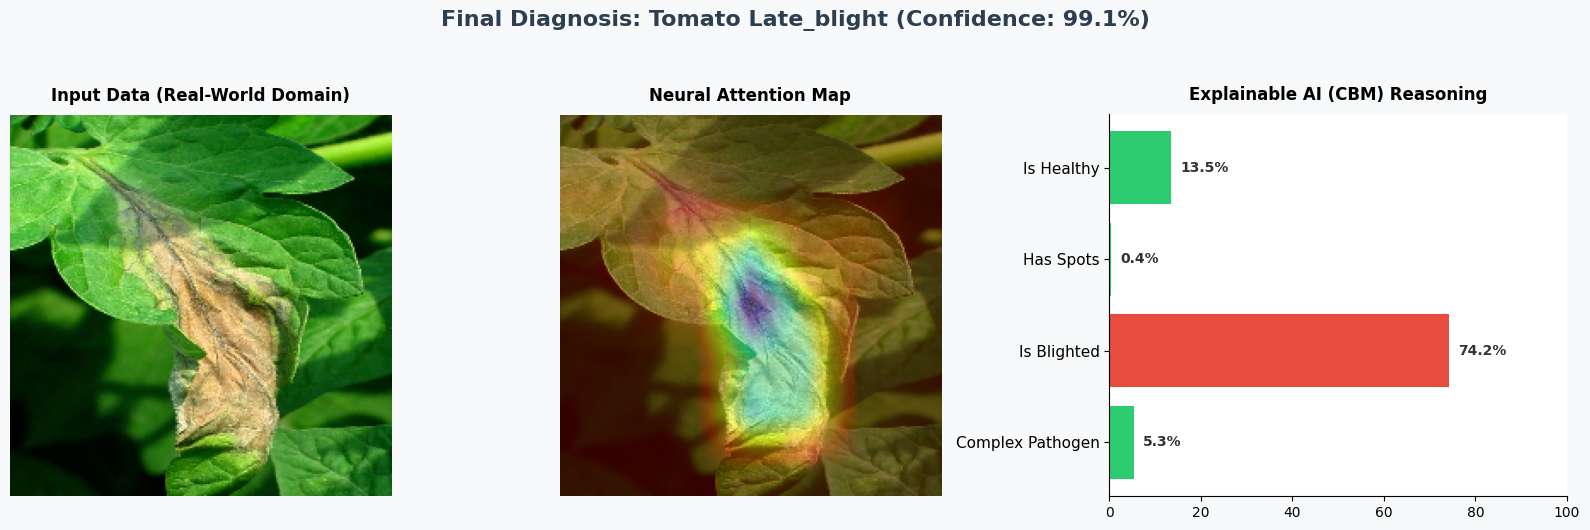

In [16]:
# THE 3-PANEL EXECUTIVE VISUAL
import matplotlib.pyplot as plt
import cv2
import numpy as np
import tensorflow as tf

# Rebuild our labels
selected_classes = [
    "Pepper Bacterial_spot", "Pepper healthy", "Potato Early_blight",
    "Potato Late_blight", "Potato healthy", "Tomato Bacterial_spot",
    "Tomato Early_blight", "Tomato Late_blight", "Tomato Leaf_Mold",
    "Tomato Septoria_leaf_spot", "Tomato Spider_mites",
    "Tomato Target_Spot", "Tomato YellowLeaf_Curl_Virus",
    "Tomato mosaic_virus", "Tomato healthy"
]
concept_names = ["Is Healthy", "Has Spots", "Is Blighted", "Complex Pathogen"]

print("[OPERATION] Processing Image & Extracting Neural Features...")

# 1. Process Image
img = cv2.imread(image_file)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_resized = cv2.resize(img_rgb, (224, 224))
img_tensor = np.expand_dims(img_resized.astype(np.float32), axis=0)

# 2. Run Inference
concepts_pred, disease_pred = model.predict(img_tensor, verbose=0)

pred_idx = np.argmax(disease_pred[0])
pred_disease = selected_classes[pred_idx]
confidence = disease_pred[0][pred_idx] * 100
last_conv_layer = None

# Scan backwards
for layer in reversed(model.layers):
    try:
        # We want the last spatial layer (Batch, Height, Width, Channels)
        if len(layer.output.shape) == 4:
            last_conv_layer = layer
            break
    except Exception:
        continue

if last_conv_layer is None:
    raise ValueError("Could not dynamically locate the Convolutional backbone.")

print(f"[SUCCESS] Intercepted neural pathways at: {last_conv_layer.name}")
feature_extractor = tf.keras.Model(inputs=model.inputs, outputs=last_conv_layer.output)
features = feature_extractor.predict(img_tensor, verbose=0)

# 4. Generate Heatmap
heatmap = np.mean(features[0], axis=-1)
heatmap = np.maximum(heatmap, 0) / np.max(heatmap) # Normalize
heatmap = cv2.resize(heatmap, (img_resized.shape[1], img_resized.shape[0]))
heatmap_color = cv2.applyColorMap(np.uint8(255 * heatmap), cv2.COLORMAP_JET)
superimposed_img = cv2.addWeighted(img_resized, 0.6, heatmap_color, 0.4, 0)

print("[SUCCESS] Features extracted. Rendering 3-Panel Dashboard...")

# THE PRESENTATION
fig, ax = plt.subplots(1, 3, figsize=(16, 5), gridspec_kw={'width_ratios': [1, 1, 1.2]})
fig.patch.set_facecolor('#f8f9fa')

# Panel 1: Original Image
ax[0].imshow(img_resized)
ax[0].set_title("Input Data (Real-World Domain)", fontsize=12, fontweight='bold', pad=10)
ax[0].axis('off')

# Panel 2: AI Heatmap
ax[1].imshow(superimposed_img)
ax[1].set_title("Neural Attention Map", fontsize=12, fontweight='bold', pad=10)
ax[1].axis('off')

# Panel 3: Concept Bottleneck Bar Chart
y_pos = np.arange(len(concept_names))
concept_probs = concepts_pred[0] * 100

bars = ax[2].barh(y_pos, concept_probs, color=['#2ecc71' if p < 30 else '#e74c3c' for p in concept_probs])
ax[2].set_yticks(y_pos)
ax[2].set_yticklabels(concept_names, fontsize=11)
ax[2].invert_yaxis()
ax[2].set_xlim(0, 100)
ax[2].set_title("Explainable AI (CBM) Reasoning", fontsize=12, fontweight='bold', pad=10)
ax[2].spines['top'].set_visible(False)
ax[2].spines['right'].set_visible(False)

for bar in bars:
    width = bar.get_width()
    ax[2].text(width + 2, bar.get_y() + bar.get_height()/2.,
            f'{width:.1f}%',
            ha='left', va='center', fontweight='bold', color='#333333')

plt.suptitle(f"Final Diagnosis: {pred_disease} (Confidence: {confidence:.1f}%)",
             fontsize=16, fontweight='heavy', y=1.05, color='#2c3e50')

plt.tight_layout()
plt.show()